# Stellar Effective Temperature (Teff) Prediction with PyTorch ANN

**Goal**: Train a feedforward neural network to predict stellar effective temperature ($T_{\text{eff}}$) from 37 photometric features (magnitudes, absolute magnitudes, and color indices) for F, G, K, and M dwarf stars.

**Approach** (based on Gemini recommendations):
- **Target**: $\log_{10}(T_{\text{eff}})$ — compresses dynamic range across F–M dwarfs
- **Loss**: MSE on log-Teff
- **Architecture**: 4-layer feedforward network with BatchNorm + Dropout
- **Split**: 70/15/15 train/val/test, stratified by spectral type
- **Evaluation**: RMSE (target <150 K), MAE, R² (target >0.90), plus diagnostic plots

## 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib
import warnings
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
sns.set_context("talk")

# --- Device configuration ---
# Check if NVIDIA GPU is available
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"Using device: {DEVICE}")

if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    # Fixed: use 'total_memory' instead of 'total_mem'
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Using device: cuda
  GPU: NVIDIA GeForce RTX 4060 Laptop GPU
  VRAM: 8.6 GB


## 2. Data Loading & Inspection

In [2]:
# --- Paths ---
PROJECT_ROOT = Path("/mnt/c/git_repo/cool-dwarf_stellar_parameter_inference_from_survey_data")
DATA_PATH = PROJECT_ROOT / "data" / "final_df" / "cool_dwarf_catalog_FGKM_consolidated.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# --- Load ---
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(f"\nSpectral type distribution:")
print(df["spectral_type_group"].value_counts().sort_index())
print(f"\nTeff range: {df['teff'].min():.0f} K — {df['teff'].max():.0f} K")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (1012986, 44)

Spectral type distribution:
spectral_type_group
F    308305
G    637001
K     32413
M     35267
Name: count, dtype: int64

Teff range: 3114 K — 8435 K

First 5 rows:


,obsid,subclass,gaia_source_id,distance_gaia_pc,mag_ps_g,mag_ps_r,mag_ps_i,mag_ps_z,mag_ps_y,teff,...,COLOR_APASS_B_V,COLOR_APASS_V_R,COLOR_SDSS_G_R,COLOR_SDSS_R_I,COLOR_X_GAIA_PS,COLOR_X_PS_2MASS,COLOR_X_2MASS_WISE,COLOR_X_APASS_SDSS,COLOR_X_SDSS_GAIA,spectral_type_group
0,300003054,F0,279692565863680,1197.577725,13.2500,13.0220,12.9750,12.9940,13.0196,6512.09,...,0.462706,0.137948,0.313614,-0.085438,-10.506981,11.117788,0.109631,0.044123,0.677562,F
1,483006140,F0,279692565863680,1197.577725,13.2500,13.0220,12.9750,12.9940,13.0196,6549.88,...,0.349425,0.143330,0.371090,0.109802,-10.489021,10.994007,0.115032,0.089858,0.368067,F
2,300014173,F6,492516785395968,592.602005,13.6308,13.2290,13.1190,13.0798,13.0525,6131.14,...,0.694350,0.086632,0.308531,-0.110482,-9.709147,9.838680,-0.025979,0.347546,0.485132,F
3,483006043,F7,492516785395968,592.602005,13.6308,13.2290,13.1190,13.0798,13.0525,6123.43,...,0.418377,0.210453,0.382709,0.219076,-9.352830,9.649268,-0.097284,0.175788,0.212616,F
4,757516200,F6,617139556505856,1350.264165,15.1017,14.7781,14.6654,14.6607,14.6290,6129.88,...,0.713250,0.299754,0.052372,-0.378514,-11.399335,11.458472,0.242923,0.957411,0.946931,F


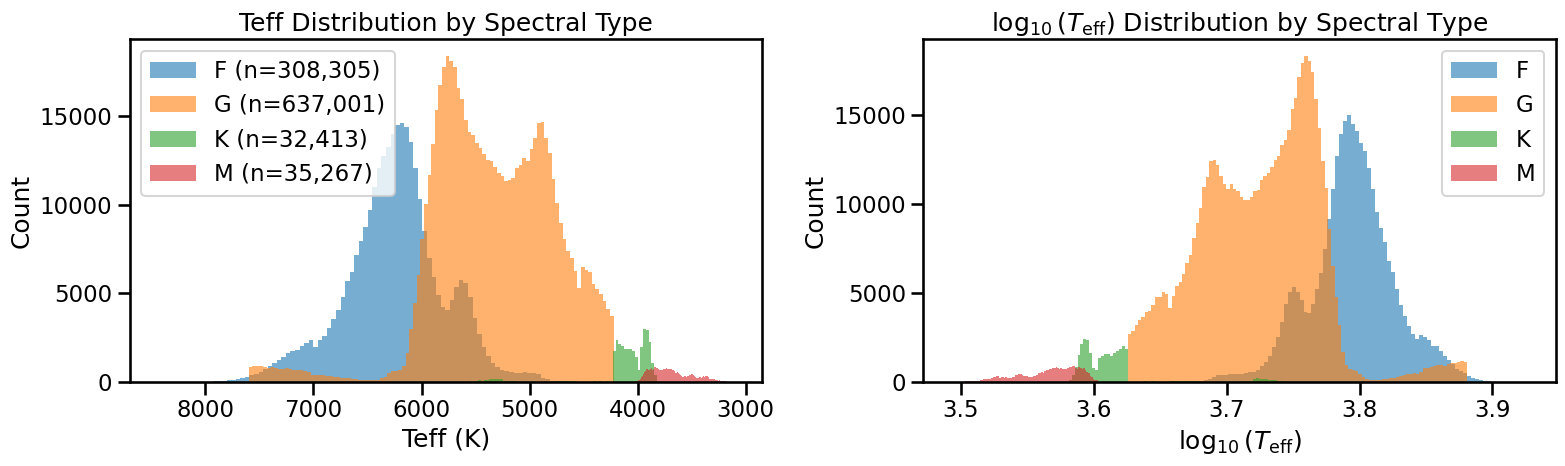

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Teff histogram by spectral type
ax = axes[0]
for stype in ["F", "G", "K", "M"]:
    subset = df[df["spectral_type_group"] == stype]
    ax.hist(subset["teff"], bins=100, alpha=0.6, label=f"{stype} (n={len(subset):,})")
ax.set_xlabel("Teff (K)")
ax.set_ylabel("Count")
ax.set_title("Teff Distribution by Spectral Type")
ax.legend()
ax.invert_xaxis()

# log10(Teff) histogram
ax = axes[1]
for stype in ["F", "G", "K", "M"]:
    subset = df[df["spectral_type_group"] == stype]
    ax.hist(np.log10(subset["teff"]), bins=100, alpha=0.6, label=f"{stype}")
ax.set_xlabel(r"$\log_{10}(T_{\mathrm{eff}})$")
ax.set_ylabel("Count")
ax.set_title(r"$\log_{10}(T_{\mathrm{eff}})$ Distribution by Spectral Type")
ax.legend()

plt.tight_layout()
plt.show()

## 3. Feature & Target Definition

In [4]:
# --- 37 photometric features ---
FEATURE_COLS = [
    # PanSTARRS apparent magnitudes (5)
    "mag_ps_g", "mag_ps_r", "mag_ps_i", "mag_ps_z", "mag_ps_y",
    # Absolute magnitudes (14)
    "A_GG", "A_BP", "A_RP", "A_J", "A_H", "A_KS", "A_W1", "A_W2",
    "A_BAP", "A_VAP", "A_RAP", "A_GSD", "A_RSD", "A_ISD",
    # Color indices (18)
    "COLOR_GAIA_BP_RP", "COLOR_GAIA_G_BP",
    "COLOR_PS_G_R", "COLOR_PS_R_I", "COLOR_PS_I_Z", "COLOR_PS_Z_Y",
    "COLOR_2MASS_J_H", "COLOR_2MASS_H_KS",
    "COLOR_WISE_W1_W2",
    "COLOR_APASS_B_V", "COLOR_APASS_V_R",
    "COLOR_SDSS_G_R", "COLOR_SDSS_R_I",
    "COLOR_X_GAIA_PS", "COLOR_X_PS_2MASS", "COLOR_X_2MASS_WISE",
    "COLOR_X_APASS_SDSS", "COLOR_X_SDSS_GAIA",
]
TARGET_COL = "teff"

print(f"Number of features: {len(FEATURE_COLS)}")
print(f"Target column: {TARGET_COL}")

# --- Extract arrays ---
X = df[FEATURE_COLS].values.astype(np.float32)
y_raw = df[TARGET_COL].values.astype(np.float32)               # Teff in Kelvin
y = np.log10(y_raw).astype(np.float32)                          # log10(Teff)
spectral_types = df["spectral_type_group"].values               # for stratified split

# --- Sanity checks ---
assert not np.any(np.isnan(X)), "NaN found in features!"
assert not np.any(np.isinf(X)), "Inf found in features!"
assert not np.any(np.isnan(y)), "NaN found in target!"
print(f"\nNo NaN or Inf in features or target")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")
print(f"  log10(Teff) range: [{y.min():.4f}, {y.max():.4f}]")
print(f"  Teff range: [{y_raw.min():.0f} K, {y_raw.max():.0f} K]")

Number of features: 37
Target column: teff

No NaN or Inf in features or target
  X shape: (1012986, 37)
  y shape: (1012986,)
  log10(Teff) range: [3.4933, 3.9261]
  Teff range: [3114 K, 8435 K]


## 4. Train / Validation / Test Split (70 / 15 / 15)

Stratified by spectral type to ensure M dwarfs (~2.4% of data) are adequately represented in all splits.

In [5]:
# --- Step 1: Split off 70% train, 30% temp ---
X_train, X_temp, y_train, y_temp, st_train, st_temp = train_test_split(
    X, y, spectral_types,
    test_size=0.30,
    random_state=SEED,
    stratify=spectral_types,
)

# --- Step 2: Split temp into 50/50 -> 15% val, 15% test ---
X_val, X_test, y_val, y_test, st_val, st_test = train_test_split(
    X_temp, y_temp, st_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=st_temp,
)

print(f"{'Split':<12} {'Samples':>10}  {'% of total':>10}")
print("-" * 36)
total = len(y)
for name, arr in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(f"{name:<12} {len(arr):>10,}  {100*len(arr)/total:>9.1f}%")
print(f"{'Total':<12} {total:>10,}  {100.0:>9.1f}%")

# Verify spectral type proportions are preserved
print(f"\nSpectral type proportions (%):")
print(f"{'Type':<6} {'Full':>8} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 40)
for stype in ["F", "G", "K", "M"]:
    full_pct = 100 * np.sum(spectral_types == stype) / len(spectral_types)
    train_pct = 100 * np.sum(st_train == stype) / len(st_train)
    val_pct = 100 * np.sum(st_val == stype) / len(st_val)
    test_pct = 100 * np.sum(st_test == stype) / len(st_test)
    print(f"{stype:<6} {full_pct:>7.1f}% {train_pct:>7.1f}% {val_pct:>7.1f}% {test_pct:>7.1f}%")

Split           Samples  % of total
------------------------------------
Train           709,090       70.0%
Validation      151,948       15.0%
Test            151,948       15.0%
Total         1,012,986      100.0%

Spectral type proportions (%):
Type       Full    Train      Val     Test
----------------------------------------
F         30.4%    30.4%    30.4%    30.4%
G         62.9%    62.9%    62.9%    62.9%
K          3.2%     3.2%     3.2%     3.2%
M          3.5%     3.5%     3.5%     3.5%


## 5. Feature Standardization

Fit `StandardScaler` on **training data only** to prevent data leakage.

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled   = scaler.transform(X_val).astype(np.float32)
X_test_scaled  = scaler.transform(X_test).astype(np.float32)

print("Feature statistics after scaling (train set):")
print(f"  Mean: {X_train_scaled.mean(axis=0).mean():.6f}  (should be ~0)")
print(f"  Std:  {X_train_scaled.std(axis=0).mean():.6f}  (should be ~1)")

Feature statistics after scaling (train set):
  Mean: 0.000000  (should be ~0)
  Std:  0.999809  (should be ~1)


## 6. PyTorch Dataset & DataLoader

In [8]:
class StellarDataset(Dataset):
    def __init__(self, features: np.ndarray, targets: np.ndarray, device):
        # Move the entire dataset to GPU immediately upon initialization
        self.X = torch.tensor(features, dtype=torch.float32).to(device)
        self.y = torch.tensor(targets, dtype=torch.float32).unsqueeze(1).to(device)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Data is already on GPU, so access is instant
        return self.X[idx], self.y[idx]

# Update initialization: pass the device
train_dataset = StellarDataset(X_train_scaled, y_train, DEVICE)
val_dataset   = StellarDataset(X_val_scaled, y_val, DEVICE)
test_dataset  = StellarDataset(X_test_scaled, y_test, DEVICE)

# --- Create dataloaders ---
BATCH_SIZE = 4096

# pin_memory only benefits CUDA; skip it on CPU
use_pin_memory = DEVICE.type == "cuda"

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=0, 
    pin_memory=False  # <--- Change this to False, or remove it entirely
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=0, 
    pin_memory=False  # <--- Change this to False, or remove it entirely
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=0, 
    pin_memory=False  # <--- Change this to False, or remove it entirely
)
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

# Quick check: grab one batch
X_batch, y_batch = next(iter(train_loader))
print(f"\nSample batch -- X: {X_batch.shape}, y: {y_batch.shape}")

Train batches: 174
Val batches:   38
Test batches:  38

Sample batch -- X: torch.Size([4096, 37]), y: torch.Size([4096, 1])


## 7. Model Architecture

Feedforward ANN with funnel architecture: `37 -> 256 -> 128 -> 64 -> 32 -> 1`

- **BatchNorm** stabilizes training on the ~1.4M-row dataset
- **Dropout** (0.15 / 0.10) prevents overfitting on the dominant G-type population
- **No output activation** — raw $\log_{10}(T_{\text{eff}})$ regression
- Total ~50K parameters: small enough to avoid overfitting, large enough to capture color–temperature nonlinearities

In [9]:
class StellarTeffNet(nn.Module):
    """
    Feedforward ANN for stellar Teff prediction.

    Architecture: 37 -> 256 -> 128 -> 64 -> 32 -> 1
    Each hidden layer: Linear -> BatchNorm -> ReLU -> Dropout
    Output: raw log10(Teff) prediction (no activation)
    """

    def __init__(self, input_dim: int = 37, dropout: float = 0.15):
        super().__init__()

        self.network = nn.Sequential(
            # Layer 1: input -> 256
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),

            # Layer 2: 256 -> 128
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            # Layer 3: 128 -> 64
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.10),

            # Layer 4: 64 -> 32
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),

            # Output: 32 -> 1
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.network(x)


# --- Instantiate model ---
model = StellarTeffNet(input_dim=len(FEATURE_COLS)).to(DEVICE)

# --- Model summary ---
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTotal parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

StellarTeffNet(
  (network): Sequential(
    (0): Linear(in_features=37, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.15, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.15, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=64, out_features=32, bias=True)
    (13): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters:     53,953
Trainable parameters: 53,953


## 8. Training Configuration

In [10]:
# --- Loss function ---
criterion = nn.MSELoss()

# --- Optimizer (Adam with L2 regularization) ---
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# --- Learning rate scheduler ---
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

# --- Early stopping config ---
MAX_EPOCHS = 100
EARLY_STOP_PATIENCE = 15

print("Training Configuration:")
print(f"  Loss:           MSE on log10(Teff)")
print(f"  Optimizer:      Adam (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"  Scheduler:      ReduceLROnPlateau (factor=0.5, patience=5)")
print(f"  Early stopping: patience={EARLY_STOP_PATIENCE} epochs")
print(f"  Max epochs:     {MAX_EPOCHS}")
print(f"  Batch size:     {BATCH_SIZE}")
print(f"  Device:         {DEVICE}")

Training Configuration:
  Loss:           MSE on log10(Teff)
  Optimizer:      Adam (lr=0.001, weight_decay=1e-05)
  Scheduler:      ReduceLROnPlateau (factor=0.5, patience=5)
  Early stopping: patience=15 epochs
  Max epochs:     100
  Batch size:     4096
  Device:         cuda


## 9. Training Loop

Standard training loop with:
- Per-epoch train/val loss tracking
- `ReduceLROnPlateau` scheduler watching validation loss
- Early stopping (patience = 15 epochs on val loss)
- Best model checkpoint saved in memory

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch, return average loss."""
    model.train()
    total_loss = 0.0
    n_samples = 0
    for X_batch, y_batch in loader:
        #X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        n_samples += X_batch.size(0)

    return total_loss / n_samples


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluate model on a dataset, return average loss."""
    model.eval()
    total_loss = 0.0
    n_samples = 0
    for X_batch, y_batch in loader:
        # X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        total_loss += loss.item() * X_batch.size(0)
        n_samples += X_batch.size(0)

    return total_loss / n_samples

In [12]:
# ===== MAIN TRAINING LOOP =====
train_losses = []
val_losses = []
lr_history = []

best_val_loss = float("inf")
best_epoch = 0
patience_counter = 0
best_model_state = None

print(f"{'Epoch':>5}  {'Train Loss':>12}  {'Val Loss':>12}  {'LR':>10}  {'Status'}")
print("-" * 65)

for epoch in range(1, MAX_EPOCHS + 1):
    # Train
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)

    # Validate
    val_loss = evaluate(model, val_loader, criterion, DEVICE)

    # Get current learning rate
    current_lr = optimizer.param_groups[0]["lr"]

    # Record history
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    lr_history.append(current_lr)

    # Learning rate scheduler step
    scheduler.step(val_loss)

    # Early stopping check
    status = ""
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        status = "* Best"
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"{epoch:>5}  {train_loss:>12.8f}  {val_loss:>12.8f}  {current_lr:>10.2e}  Early stop")
            break

    # Print progress every 5 epochs or on improvement
    if epoch % 5 == 0 or status or epoch == 1:
        print(f"{epoch:>5}  {train_loss:>12.8f}  {val_loss:>12.8f}  {current_lr:>10.2e}  {status}")

# Restore best model
model.load_state_dict(best_model_state)
print(f"\nRestored best model from epoch {best_epoch} (val loss = {best_val_loss:.8f})")

Epoch    Train Loss      Val Loss          LR  Status
-----------------------------------------------------------------
    1    4.22339534    0.40611529    1.00e-03  * Best
    2    0.05045454    0.00168213    1.00e-03  * Best
    3    0.00539951    0.00073395    1.00e-03  * Best
    4    0.00451322    0.00059553    1.00e-03  * Best
    5    0.00388092    0.00036439    1.00e-03  * Best
    8    0.00300279    0.00028883    1.00e-03  * Best
   10    0.00245451    0.00026544    1.00e-03  * Best
   12    0.00198054    0.00025042    1.00e-03  * Best
   15    0.00162024    0.00060560    1.00e-03  
   19    0.00111404    0.00022151    5.00e-04  * Best
   20    0.00104973    0.00025276    5.00e-04  
   22    0.00099786    0.00020597    5.00e-04  * Best
   25    0.00092456    0.00029840    5.00e-04  
   30    0.00080402    0.00033078    2.50e-04  
   32    0.00070005    0.00018056    2.50e-04  * Best
   35    0.00064772    0.00020599    2.50e-04  
   40    0.00058216    0.00017106    1.25e-04 

## 10. Training Diagnostics

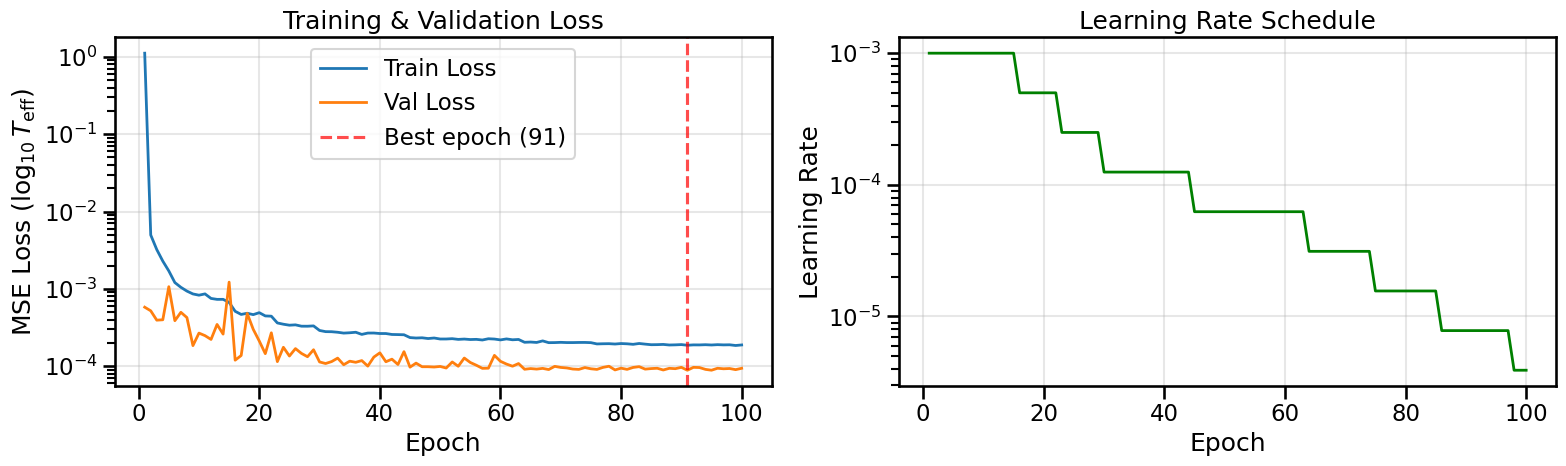

Saved: results/training_diagnostics.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Loss curves ---
ax = axes[0]
epochs_range = range(1, len(train_losses) + 1)
ax.plot(epochs_range, train_losses, label="Train Loss", linewidth=2)
ax.plot(epochs_range, val_losses, label="Val Loss", linewidth=2)
ax.axvline(best_epoch, color="red", linestyle="--", alpha=0.7,
           label=f"Best epoch ({best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel(r"MSE Loss ($\log_{10} T_{\mathrm{eff}}$)")
ax.set_title("Training & Validation Loss")
ax.legend()
ax.set_yscale("log")
ax.grid(True, alpha=0.3)

# --- Learning rate schedule ---
ax = axes[1]
ax.plot(epochs_range, lr_history, linewidth=2, color="green")
ax.set_xlabel("Epoch")
ax.set_ylabel("Learning Rate")
ax.set_title("Learning Rate Schedule")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_diagnostics.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: results/training_diagnostics.png")

## 11. Test Set Evaluation (Final Exam — Run Once)

Convert predictions from $\log_{10}(T)$ back to Kelvin before reporting metrics.

In [14]:
# --- Predict on test set ---
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        preds = model(X_batch)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(y_batch.cpu().numpy())

y_pred_log = np.concatenate(all_preds).flatten()    # log10(Teff) predicted
y_true_log = np.concatenate(all_targets).flatten()   # log10(Teff) true

# Convert back to Kelvin
y_pred_K = 10 ** y_pred_log
y_true_K = 10 ** y_true_log

# --- Compute metrics in Kelvin ---
rmse_K = np.sqrt(mean_squared_error(y_true_K, y_pred_K))
mae_K = mean_absolute_error(y_true_K, y_pred_K)
r2 = r2_score(y_true_K, y_pred_K)
median_ae_K = np.median(np.abs(y_pred_K - y_true_K))

# Also compute metrics in log10 space
rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
mae_log = mean_absolute_error(y_true_log, y_pred_log)

print("=" * 50)
print("       TEST SET EVALUATION RESULTS")
print("=" * 50)
print(f"\n  In Kelvin:")
print(f"    RMSE:             {rmse_K:>8.1f} K")
print(f"    MAE:              {mae_K:>8.1f} K")
print(f"    Median AE:        {median_ae_K:>8.1f} K")
print(f"    R\u00b2:               {r2:>8.5f}")
print(f"\n  In log10(Teff):")
print(f"    RMSE:             {rmse_log:>8.6f}")
print(f"    MAE:              {mae_log:>8.6f}")

# --- Per spectral type metrics ---
print(f"\n{'_' * 50}")
print(f"  Per-Spectral-Type Breakdown (Kelvin)")
print(f"{'_' * 50}")
print(f"  {'Type':<6} {'N':>8} {'RMSE':>8} {'MAE':>8} {'MedAE':>8} {'R2':>8}")
print(f"  {'----':<6} {'----':>8} {'----':>8} {'----':>8} {'-----':>8} {'--':>8}")

for stype in ["F", "G", "K", "M"]:
    mask = st_test == stype
    if mask.sum() == 0:
        continue
    yt = y_true_K[mask]
    yp = y_pred_K[mask]
    st_rmse = np.sqrt(mean_squared_error(yt, yp))
    st_mae = mean_absolute_error(yt, yp)
    st_medae = np.median(np.abs(yp - yt))
    st_r2 = r2_score(yt, yp)
    print(f"  {stype:<6} {mask.sum():>8,} {st_rmse:>8.1f} {st_mae:>8.1f} {st_medae:>8.1f} {st_r2:>8.4f}")

       TEST SET EVALUATION RESULTS

  In Kelvin:
    RMSE:                151.2 K
    MAE:                 112.2 K
    Median AE:            87.1 K
    R²:                0.96380

  In log10(Teff):
    RMSE:             0.011633
    MAE:              0.008802

__________________________________________________
  Per-Spectral-Type Breakdown (Kelvin)
__________________________________________________
  Type          N     RMSE      MAE    MedAE       R2
  ----       ----     ----     ----    -----       --
  F        46,246    183.5    138.4    110.2   0.8433
  G        95,550    136.9    102.1     79.7   0.9413
  K         4,862    114.8     87.1     69.5   0.8961
  M         5,290    105.8     88.8     82.5   0.6960


## 12. Visualization — One-to-One Plot (Predicted vs True Teff)

A tight 45° line indicates accurate predictions. Watch for S-curve bias (regression to the mean).

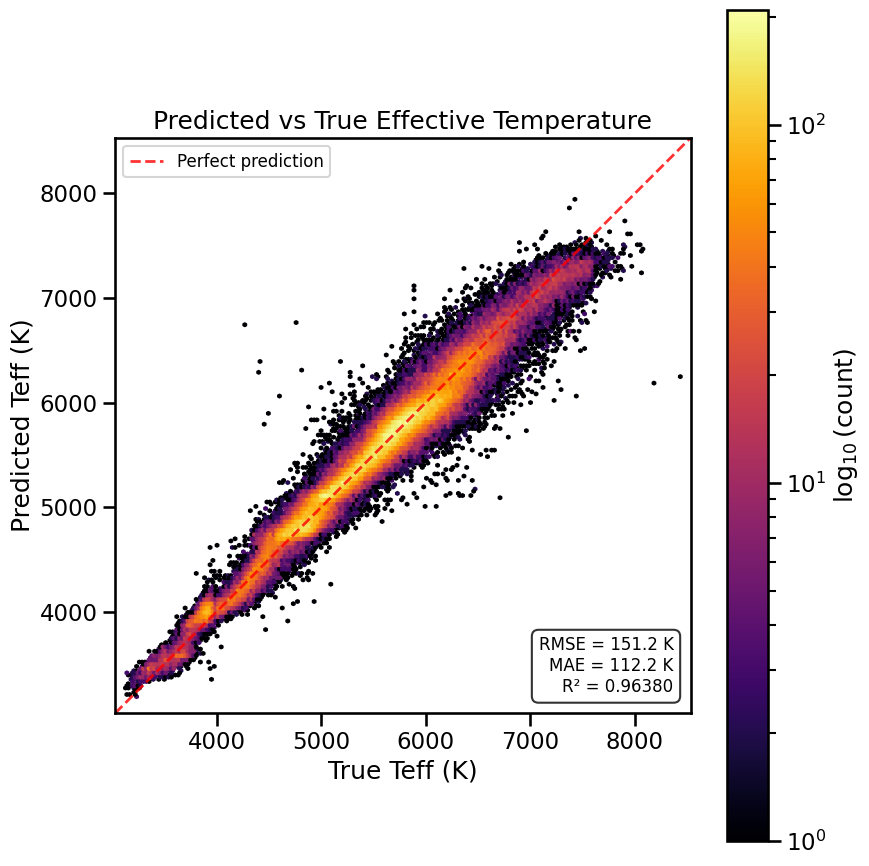

Saved: results/one_to_one_plot.png


In [15]:
fig, ax = plt.subplots(figsize=(9, 9))

# Hexbin for density visualization (too many points for scatter)
hb = ax.hexbin(y_true_K, y_pred_K, gridsize=200, cmap="inferno", mincnt=1, bins="log")
cb = plt.colorbar(hb, ax=ax, label=r"$\log_{10}$(count)")

# Perfect prediction line
lims = [min(y_true_K.min(), y_pred_K.min()) - 100,
        max(y_true_K.max(), y_pred_K.max()) + 100]
ax.plot(lims, lims, "r--", linewidth=2, alpha=0.8, label="Perfect prediction")

ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("True Teff (K)")
ax.set_ylabel("Predicted Teff (K)")
ax.set_title("Predicted vs True Effective Temperature")
ax.set_aspect("equal")
ax.legend(loc="upper left", fontsize=12)

# Annotate metrics
textstr = f"RMSE = {rmse_K:.1f} K\nMAE = {mae_K:.1f} K\nR\u00b2 = {r2:.5f}"
ax.text(0.97, 0.03, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment="bottom", horizontalalignment="right",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig(RESULTS_DIR / "one_to_one_plot.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: results/one_to_one_plot.png")

## 13. Visualization — Residual Plot (The Debugger)

Residuals should be centered on 0 with no systematic structure. A smiley-face/S-curve shape indicates the model missed a pattern.

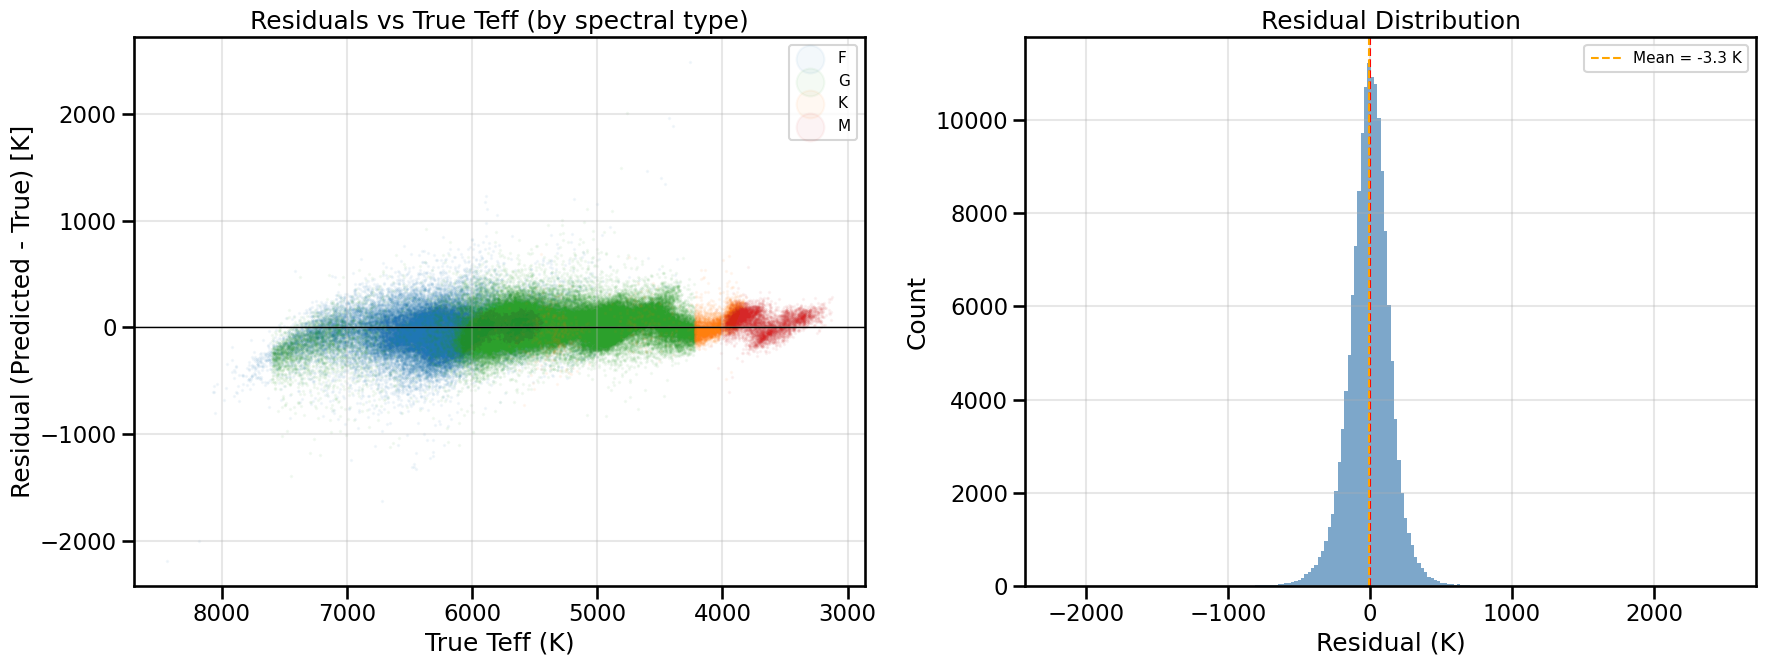

Saved: results/residual_plot.png


In [16]:
residuals_K = y_pred_K - y_true_K

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Panel A: Residuals vs True Teff, colored by spectral type ---
ax = axes[0]
colors_map = {"F": "#1f77b4", "G": "#2ca02c", "K": "#ff7f0e", "M": "#d62728"}
for stype in ["F", "G", "K", "M"]:
    mask = st_test == stype
    ax.scatter(y_true_K[mask], residuals_K[mask], alpha=0.05, s=1,
               color=colors_map[stype], label=stype, rasterized=True)
ax.axhline(0, color="black", linestyle="-", linewidth=1)
ax.set_xlabel("True Teff (K)")
ax.set_ylabel("Residual (Predicted - True) [K]")
ax.set_title("Residuals vs True Teff (by spectral type)")
ax.legend(markerscale=20, fontsize=11)
ax.invert_xaxis()
ax.grid(True, alpha=0.3)

# --- Panel B: Residual histogram ---
ax = axes[1]
ax.hist(residuals_K, bins=200, edgecolor="none", alpha=0.7, color="steelblue")
ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
ax.axvline(np.mean(residuals_K), color="orange", linestyle="--", linewidth=1.5,
           label=f"Mean = {np.mean(residuals_K):.1f} K")
ax.set_xlabel("Residual (K)")
ax.set_ylabel("Count")
ax.set_title("Residual Distribution")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "residual_plot.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: results/residual_plot.png")

## 14. Visualization — HR Diagram (Physics Sanity Check)

Side-by-side HR diagrams colored by **true** vs **predicted** Teff. The color gradient should look smooth and physically consistent — cool M-dwarfs (red) in the bottom-right, hot F-dwarfs (blue) in the upper-left.

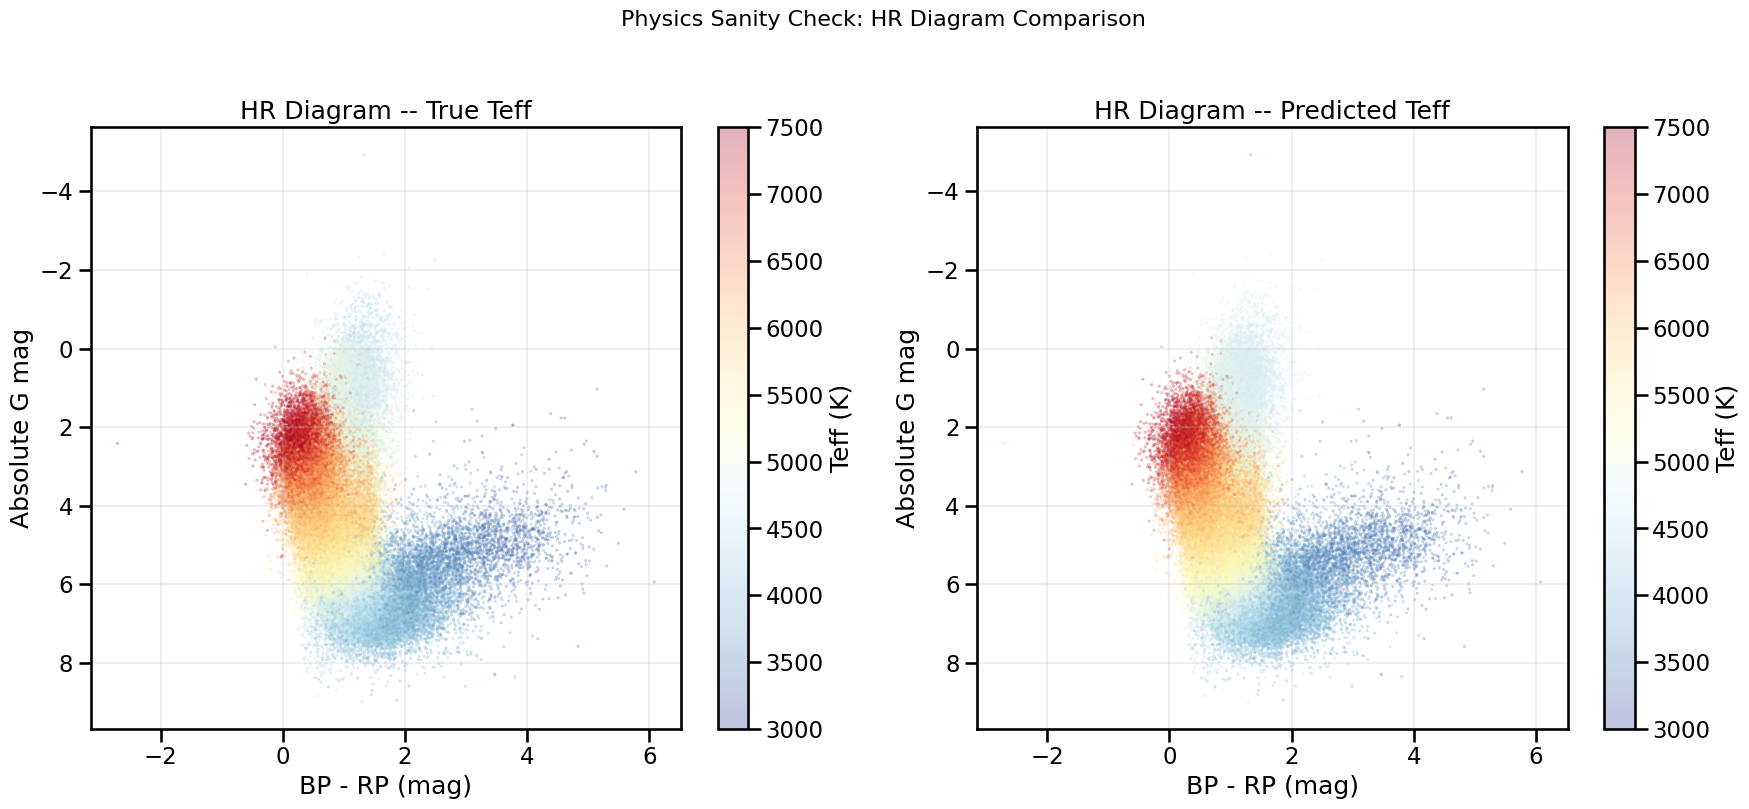

Saved: results/hr_diagram_comparison.png


In [17]:
# Retrieve unscaled COLOR_GAIA_BP_RP and A_GG from the test set
bp_rp_idx = FEATURE_COLS.index("COLOR_GAIA_BP_RP")
agg_idx = FEATURE_COLS.index("A_GG")

test_bp_rp = X_test[:, bp_rp_idx]   # original (unscaled) values
test_agg = X_test[:, agg_idx]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Panel A: HR diagram colored by TRUE Teff ---
ax = axes[0]
sc1 = ax.scatter(test_bp_rp, test_agg, c=y_true_K, cmap="RdYlBu_r",
                 s=0.5, alpha=0.3, vmin=3000, vmax=7500, rasterized=True)
ax.set_xlabel("BP - RP (mag)")
ax.set_ylabel("Absolute G mag")
ax.set_title("HR Diagram -- True Teff")
ax.invert_yaxis()
plt.colorbar(sc1, ax=ax, label="Teff (K)")
ax.grid(True, alpha=0.2)

# --- Panel B: HR diagram colored by PREDICTED Teff ---
ax = axes[1]
sc2 = ax.scatter(test_bp_rp, test_agg, c=y_pred_K, cmap="RdYlBu_r",
                 s=0.5, alpha=0.3, vmin=3000, vmax=7500, rasterized=True)
ax.set_xlabel("BP - RP (mag)")
ax.set_ylabel("Absolute G mag")
ax.set_title("HR Diagram -- Predicted Teff")
ax.invert_yaxis()
plt.colorbar(sc2, ax=ax, label="Teff (K)")
ax.grid(True, alpha=0.2)

plt.suptitle("Physics Sanity Check: HR Diagram Comparison", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "hr_diagram_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: results/hr_diagram_comparison.png")

## 15. Save Model & Results

In [ ]:
# --- Save best model state dict ---
model_save_path = MODELS_DIR / "stellar_teff_ann_best.pth"
torch.save({
    "model_state_dict": best_model_state,
    "input_dim": len(FEATURE_COLS),
    "feature_cols": FEATURE_COLS,
    "best_epoch": best_epoch,
    "best_val_loss": best_val_loss,
    "architecture": str(model),
}, model_save_path)
print(f"Model saved to {model_save_path}")

# --- Save scaler ---
scaler_save_path = MODELS_DIR / "scaler.pkl"
joblib.dump(scaler, scaler_save_path)
print(f"Scaler saved to {scaler_save_path}")

# --- Save test metrics ---
metrics = {
    "rmse_kelvin": round(float(rmse_K), 2),
    "mae_kelvin": round(float(mae_K), 2),
    "median_ae_kelvin": round(float(median_ae_K), 2),
    "r2_score": round(float(r2), 6),
    "rmse_log10": round(float(rmse_log), 6),
    "mae_log10": round(float(mae_log), 6),
    "best_epoch": best_epoch,
    "total_epochs_run": len(train_losses),
    "n_train": len(y_train),
    "n_val": len(y_val),
    "n_test": len(y_test),
    "n_features": len(FEATURE_COLS),
}
metrics_path = RESULTS_DIR / "test_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)
print(f"Metrics saved to {metrics_path}")

print(f"\n{'=' * 50}")
print(f"  All artifacts saved successfully!")
print(f"{'=' * 50}")